In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import uniform
sns.set_style(style = 'whitegrid')
pd.set_option('display.max_columns', None)
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime


# Import & Explore
---



In [ ]:
df = pd.read_csv(r"hotel_bookings.csv")
df.shape



(119390, 32)

In [ ]:
df.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,0.0,0,FB,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,303.0,NaN,0,Transient,103.0,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,82.0,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,0.0,0,HB,PRT,Offline TA/TO,TA/TO,0,0,0,D,D,0,No Deposit,15.0,NaN,0,Transient,105.5,0,0,Canceled,2015-04-22


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
df.describe(include="all")

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,119390,119390.000000,119390.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390,118902,119390,119390,119390.000000,119390.000000,119390.000000,119390,119390,119390.000000,119390,103050.000000,6797.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390,119390
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,177,8,5,NaN,NaN,NaN,10,12,NaN,3,NaN,NaN,NaN,4,NaN,NaN,NaN,3,926
top,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB,PRT,Online TA,TA/TO,NaN,NaN,NaN,A,A,NaN,No Deposit,NaN,NaN,NaN,Transient,NaN,NaN,NaN,Check-Out,2015-10-21
freq,79330,NaN,NaN,NaN,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92310,48590,56477,97870,NaN,NaN,NaN,85994,74053,NaN,104641,NaN,NaN,NaN,89613,NaN,NaN,NaN,75166,1461
mean,NaN,0.370416,104.011416,2016.156554,NaN,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,NaN,NaN,NaN,NaN,0.031912,0.087118,0.137097,NaN,NaN,0.221124,NaN,86.693382,189.266735,2.321149,NaN,101.831122,0.062518,0.571363,NaN,NaN
std,NaN,0.482918,106.863097,0.707476,NaN,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,NaN,NaN,NaN,NaN,0.175767,0.844336,1.497437,NaN,NaN,0.652306,NaN,110.774548,131.655015,17.594721,NaN,50.535790,0.245291,0.792798,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,1.000000,6.000000,0.000000,NaN,-6.380000,0.000000,0.000000,NaN,NaN
25%,NaN,0.000000,18.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,9.000000,62.000000,0.000000,NaN,69.290000,0.000000,0.000000,NaN,NaN
50%,NaN,0.000000,69.000000,2016.000000,NaN,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,14.000000,179.000000,0.000000,NaN,94.575000,0.000000,0.000000,NaN,NaN
75%,NaN,1.000000,160.000000,2017.000000,NaN,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,229.000000,270.000000,0.000000,NaN,126.000000,0.000000,1.000000,NaN,NaN


In [ ]:
df.count()

,0
hotel,119390
is_canceled,119390
lead_time,119390
arrival_date_year,119390
arrival_date_month,119390
arrival_date_week_number,119390
arrival_date_day_of_month,119390
stays_in_weekend_nights,119390
stays_in_week_nights,119390
adults,119390



# Data Cleaning & Transformation
---



In [ ]:
df.drop_duplicates(inplace=True)
df.shape


(87396, 32)

In [ ]:
df=df.replace(['','Nan','None','NA'],np.nan)
total = df.isnull().sum().sort_values(ascending=False)
percent = (100*df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head()

,Total,Percent
company,82137,93.982562
agent,12193,13.951439
country,452,0.517186
children,4,0.004577
arrival_date_month,0,0.000000


## Children


---




In [ ]:
df['children'].describe()

,children
count,87392.000000
mean,0.138640
std,0.455881
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,10.000000


In [ ]:
df['children'].value_counts()

,count
children,
0.0,79028
1.0,4695
2.0,3593
3.0,75
10.0,1


In [ ]:
df[df['children'].isnull()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
40600,City Hotel,1,2,2015,August,32,3,1,0,2,NaN,0,BB,PRT,Undefined,Undefined,0,0,0,B,B,0,No Deposit,NaN,NaN,0,Transient-Party,12.0,0,1,Canceled,2015-08-01
40667,City Hotel,1,1,2015,August,32,5,0,2,2,NaN,0,BB,PRT,Direct,Undefined,0,0,0,B,B,0,No Deposit,14.0,NaN,0,Transient-Party,12.0,0,1,Canceled,2015-08-04
40679,City Hotel,1,1,2015,August,32,5,0,2,3,NaN,0,BB,PRT,Undefined,Undefined,0,0,0,B,B,0,No Deposit,NaN,NaN,0,Transient-Party,18.0,0,2,Canceled,2015-08-04
41160,City Hotel,1,8,2015,August,33,13,2,5,2,NaN,0,BB,PRT,Online TA,Undefined,0,0,0,B,B,0,No Deposit,9.0,NaN,0,Transient-Party,76.5,0,1,Canceled,2015-08-09


In [ ]:

# df['children']=df['children'].fillna(0)
df.dropna(subset=['children'],inplace=True)
df.shape

(87392, 32)

In [ ]:
df['children']=df['children'].astype(int)

## Country

---



In [ ]:
df['country'].describe()

,country
count,86940
unique,177
top,PRT
freq,27449


In [ ]:
df['country'].value_counts()

,count
country,
PRT,27449
GBR,10433
FRA,8837
ESP,7252
DEU,5387
...,...
MRT,1
KIR,1
SDN,1


In [ ]:
df[df['country'].isnull()]



,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
30,Resort Hotel,0,118,2015,July,27,1,4,10,1,0,0,BB,NaN,Direct,Direct,0,0,0,A,A,2,No Deposit,NaN,NaN,0,Transient,62.0,0,2,Check-Out,2015-07-15
4127,Resort Hotel,1,0,2016,February,8,15,0,0,0,0,0,SC,NaN,Offline TA/TO,TA/TO,0,0,0,P,P,0,No Deposit,NaN,383.0,0,Transient,0.0,0,0,Canceled,2016-02-15
7092,Resort Hotel,1,8,2016,July,30,21,0,1,1,0,0,BB,NaN,Corporate,Corporate,0,0,0,A,A,0,No Deposit,NaN,204.0,0,Transient,73.0,0,2,Canceled,2016-07-20
7860,Resort Hotel,1,39,2016,August,36,30,0,5,2,0,0,HB,NaN,Direct,Direct,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Transient,159.0,0,5,Canceled,2016-07-22
8779,Resort Hotel,1,0,2016,October,42,13,0,1,1,0,0,BB,NaN,Corporate,Corporate,0,0,0,A,A,0,No Deposit,NaN,457.0,0,Transient,50.0,0,0,Canceled,2016-10-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60651,City Hotel,1,0,2016,November,47,17,4,11,0,0,0,SC,NaN,Corporate,Direct,0,0,0,P,P,0,No Deposit,NaN,279.0,0,Transient,0.0,0,0,Canceled,2016-11-17
61244,City Hotel,1,0,2016,December,50,6,0,0,0,0,0,SC,NaN,Complementary,Corporate,0,0,0,P,P,0,No Deposit,NaN,279.0,0,Transient,0.0,0,0,Canceled,2016-12-06
65907,City Hotel,1,0,2017,April,15,10,0,0,0,0,0,SC,NaN,Complementary,Corporate,0,0,0,P,P,0,No Deposit,NaN,279.0,0,Transient,0.0,0,0,Canceled,2017-04-10
80830,City Hotel,0,4,2015,November,48,23,1,2,1,0,0,BB,NaN,Groups,TA/TO,0,0,0,A,A,0,No Deposit,37.0,NaN,0,Transient-Party,70.0,0,0,Check-Out,2015-11-26


In [ ]:
# df['country']=df['country'].fillna(df['country'].mode()[0])
# df['country']=df['country'].fillna("Unknown")
df.dropna(subset=['country'],inplace=True)
df.shape

(86940, 32)

## Agent

---



In [ ]:
df['agent'].value_counts()

,count
agent,
9.0,28757
240.0,12977
14.0,3347
7.0,3300
250.0,2764
...,...
388.0,1
453.0,1
304.0,1


In [ ]:
df[df['agent'].isnull()]


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,NaN,NaN,0,Transient,107.00,0,0,Check-Out,2015-07-03
18,Resort Hotel,0,0,2015,July,27,1,0,1,2,0,0,BB,FRA,Corporate,Corporate,0,0,0,A,G,0,No Deposit,NaN,110.0,0,Transient,107.42,0,0,Check-Out,2015-07-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119124,City Hotel,0,0,2017,August,35,29,0,1,1,0,0,BB,PRT,Complementary,Corporate,0,0,0,A,A,0,No Deposit,NaN,72.0,0,Transient,0.00,0,2,Check-Out,2017-08-30
119151,City Hotel,0,0,2017,August,35,29,0,1,2,2,0,BB,NLD,Direct,Direct,0,0,0,G,G,0,No Deposit,NaN,NaN,0,Transient,270.00,0,0,Check-Out,2017-08-30
119166,City Hotel,0,0,2017,August,35,30,0,1,1,0,0,BB,BRA,Direct,Direct,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Transient,140.00,0,0,Check-Out,2017-08-31
119215,City Hotel,0,2,2017,August,35,31,0,1,1,0,0,SC,LBN,Direct,Direct,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Transient,140.00,0,2,Check-Out,2017-09-01


In [ ]:
df['agent']=df['agent'].fillna(0)
df.shape

(86940, 32)

In [ ]:
df.loc[df['agent']==0,'has_agent']=False
df.loc[df['agent']!=0,'has_agent']=True


In [ ]:
df['agent']=df['agent'].astype(int)


## Company

---



In [ ]:
df['company'].value_counts()

,count
company,
40.0,851
223.0,503
45.0,238
153.0,206
219.0,131
...,...
273.0,1
71.0,1
284.0,1


In [ ]:
df[df['company'].isnull()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,has_agent
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01,False
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01,False
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02,False
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02,True
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,0,0,BB,BEL,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,394,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06,True
119386,City Hotel,0,102,2017,August,35,31,2,5,3,0,0,BB,FRA,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,9,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07,True
119387,City Hotel,0,34,2017,August,35,31,2,5,2,0,0,BB,DEU,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07,True
119388,City Hotel,0,109,2017,August,35,31,2,5,2,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,89,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07,True


In [ ]:
df['company']=df['company'].fillna(0)
df.shape

(86940, 33)

In [ ]:
df.loc[df['company']==0,'has_company']=False
df.loc[df['company']!=0,'has_company']=True

In [ ]:
df['company']=df['company'].astype(int)


## Is Canceled

---



In [ ]:
df['is_canceled']=df['is_canceled'].astype(bool)

##  Arrival Date

---



In [ ]:
arrival_date_month_number = [str(datetime.strptime(i,"%B").month) for i in df['arrival_date_month'].astype(str)]
df.insert(7,'arrival_date',df['arrival_date_year'].astype(str)+'-'+arrival_date_month_number+'-'+df['arrival_date_day_of_month'].astype(str))


## Is Repeated Guest

---



In [ ]:
df['is_repeated_guest']=df['is_repeated_guest'].astype(bool)

## Meal Label

---



In [ ]:
df['meal'].value_counts()

,count
meal,
BB,67562
SC,9474
HB,9056
Undefined,488
FB,360


In [ ]:
df.insert(14,'meal_label',np.where(df['meal']=='BB','Bed & Breakfast',np.where(df['meal']=='SC','No Meal Package',np.where(df['meal']=='HB','Half Board',np.where(df['meal']=='Undefined','No Meal Package',np.where(df['meal']=='FB','Full Board','No Meal Package'))))))

In [ ]:
df[['meal_label','meal']].value_counts()

,,count
meal_label,meal,
Bed & Breakfast,BB,67562
No Meal Package,SC,9474
Half Board,HB,9056
No Meal Package,Undefined,488
Full Board,FB,360


## Market Segment

---



In [ ]:
df['market_segment'].value_counts()


,count
market_segment,
Online TA,51543
Offline TA/TO,13857
Direct,11647
Groups,4937
Corporate,4031
Complementary,698
Aviation,227


In [ ]:
market_segment_label ={
    "Online TA":"Online Travel Agent",
    "Offline TA/TO":"Offline Travel Agent / Tour Operator",
    "Direct":"Direct",
    "Groups":"Groups",
    "Corporate":"Corporate",
    "Complementary":"Complementary",
    "Aviation":"Aviation"
}

In [ ]:
df.insert(17,'market_segment_label',[market_segment_label[i] for i in df['market_segment']])

In [ ]:
df[['market_segment_label','market_segment']].value_counts()

,,count
market_segment_label,market_segment,
Online Travel Agent,Online TA,51543
Offline Travel Agent / Tour Operator,Offline TA/TO,13857
Direct,Direct,11647
Groups,Groups,4937
Corporate,Corporate,4031
Complementary,Complementary,698
Aviation,Aviation,227


## Distribution Channel

---



In [ ]:
df['distribution_channel'].value_counts()


,count
distribution_channel,
TA/TO,69028
Direct,12827
Corporate,4903
GDS,181
Undefined,1


In [ ]:
df[df['distribution_channel']=='Undefined']

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,arrival_date,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,meal_label,country,market_segment,market_segment_label,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,has_agent,has_company
14594,Resort Hotel,False,103,2015,July,28,5,2015-7-5,2,3,2,1,0,HB,Half Board,PRT,Direct,Direct,Undefined,False,0,0,A,A,0,No Deposit,0,0,0,Transient,112.7,1,2,Check-Out,2015-07-10,False,False


In [ ]:
distribution_channel_label ={
    "TA/TO":"Travel Agent / Tour Operator",
    "Direct":"Direct",
    "Corporate":"Corporate",
    "GDS":"Global Distribution System",
    "Undefined":"Undefined"}

In [ ]:
df.insert(19,'distribution_channel_label',df['distribution_channel'].map(distribution_channel_label))

In [ ]:
df[['distribution_channel_label','distribution_channel']].value_counts()


,,count
distribution_channel_label,distribution_channel,
Travel Agent / Tour Operator,TA/TO,69028
Direct,Direct,12827
Corporate,Corporate,4903
Global Distribution System,GDS,181
Undefined,Undefined,1


## ADR

---



In [ ]:
df.rename(columns={'adr':'average_daily_rate(ADR)'},inplace=True)

## Country

---



In [ ]:
df['country'].value_counts()

,count
country,
PRT,27449
GBR,10433
FRA,8837
ESP,7252
DEU,5387
...,...
MRT,1
KIR,1
SDN,1


In [ ]:
# import requests
# headers = {'User-Agent': 'Mozilla/5.0'}
# resp = requests.get('https://en.wikipedia.org/wiki/List_of_ISO_3166_country_codes', headers=headers)
# tables = pd.read_html(resp.text)
# country_list = tables[0]  # the main ISO 3166 table
# country_list
country_df=pd.read_csv(r'iso3166_country_codes.csv')

In [ ]:
country_df

,country_name,alpha2,alpha3
0,Afghanistan,AF,AFG
1,Åland Islands,AX,ALA
2,Albania,AL,ALB
3,Algeria,DZ,DZA
4,American Samoa,AS,ASM
...,...,...,...
244,Wallis and Futuna,WF,WLF
245,Western Sahara,EH,ESH
246,Yemen,YE,YEM
247,Zambia,ZM,ZMB


In [ ]:
# def country_name(code):
#   if len(country_df.loc[country_df['alpha3']==code,'country_name'])!=0:
#     return country_df.loc[country_df['alpha3']==code,'country_name'].values[0]
#   else:
#     return code

# df.insert(16,'country_name',df['country'].apply(country_name))
# df['country_name'].value_counts()

In [ ]:

df=pd.merge(country_df[['alpha3','country_name']],df,"right",left_on='alpha3',right_on='country')
df.insert(18,'country_name_1',df['country_name'])
df=df.drop(columns=['alpha3','country_name'])
df.rename(columns={'country_name_1':'country_name'},inplace=True)
df.loc[df['country']=='CN','country_name']='China'
df.loc[df['country']=='TMP','country_name']='Timor-Leste'
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,arrival_date,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,meal_label,country,country_name,market_segment,market_segment_label,distribution_channel,distribution_channel_label,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,average_daily_rate(ADR),required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,has_agent,has_company
0,Resort Hotel,False,342,2015,July,27,1,2015-7-1,0,0,2,0,0,BB,Bed & Breakfast,PRT,Portugal,Direct,Direct,Direct,Direct,False,0,0,C,C,3,No Deposit,0,0,0,Transient,0.00,0,0,Check-Out,2015-07-01,False,False
1,Resort Hotel,False,737,2015,July,27,1,2015-7-1,0,0,2,0,0,BB,Bed & Breakfast,PRT,Portugal,Direct,Direct,Direct,Direct,False,0,0,C,C,4,No Deposit,0,0,0,Transient,0.00,0,0,Check-Out,2015-07-01,False,False
2,Resort Hotel,False,7,2015,July,27,1,2015-7-1,0,1,1,0,0,BB,Bed & Breakfast,GBR,United Kingdom,Direct,Direct,Direct,Direct,False,0,0,A,C,0,No Deposit,0,0,0,Transient,75.00,0,0,Check-Out,2015-07-02,False,False
3,Resort Hotel,False,13,2015,July,27,1,2015-7-1,0,1,1,0,0,BB,Bed & Breakfast,GBR,United Kingdom,Corporate,Corporate,Corporate,Corporate,False,0,0,A,A,0,No Deposit,304,0,0,Transient,75.00,0,0,Check-Out,2015-07-02,True,False
4,Resort Hotel,False,14,2015,July,27,1,2015-7-1,0,2,2,0,0,BB,Bed & Breakfast,GBR,United Kingdom,Online TA,Online Travel Agent,TA/TO,Travel Agent / Tour Operator,False,0,0,A,A,0,No Deposit,240,0,0,Transient,98.00,0,1,Check-Out,2015-07-03,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86935,City Hotel,False,23,2017,August,35,30,2017-8-30,2,5,2,0,0,BB,Bed & Breakfast,BEL,Belgium,Offline TA/TO,Offline Travel Agent / Tour Operator,TA/TO,Travel Agent / Tour Operator,False,0,0,A,A,0,No Deposit,394,0,0,Transient,96.14,0,0,Check-Out,2017-09-06,True,False
86936,City Hotel,False,102,2017,August,35,31,2017-8-31,2,5,3,0,0,BB,Bed & Breakfast,FRA,France,Online TA,Online Travel Agent,TA/TO,Travel Agent / Tour Operator,False,0,0,E,E,0,No Deposit,9,0,0,Transient,225.43,0,2,Check-Out,2017-09-07,True,False
86937,City Hotel,False,34,2017,August,35,31,2017-8-31,2,5,2,0,0,BB,Bed & Breakfast,DEU,Germany,Online TA,Online Travel Agent,TA/TO,Travel Agent / Tour Operator,False,0,0,D,D,0,No Deposit,9,0,0,Transient,157.71,0,4,Check-Out,2017-09-07,True,False
86938,City Hotel,False,109,2017,August,35,31,2017-8-31,2,5,2,0,0,BB,Bed & Breakfast,GBR,United Kingdom,Online TA,Online Travel Agent,TA/TO,Travel Agent / Tour Operator,False,0,0,A,A,0,No Deposit,89,0,0,Transient,104.40,0,0,Check-Out,2017-09-07,True,False


## Miss Match Room

---



In [ ]:
df['miss_match_room']=df['reserved_room_type']!=df['assigned_room_type']

## Nights

---



In [ ]:
wrong_data=(df['stays_in_weekend_nights']==0 )&(df['stays_in_week_nights']==0)&(df['is_canceled']==False)
print(df[wrong_data].shape[0] / df.shape[0] * 100)
df=df[~wrong_data]

0.7096848401196227


# Visualizations

---



## Home

---



In [ ]:
df.insert(5,'arrival_date_month_number',[(datetime.strptime(i,"%B").month) for i in df['arrival_date_month'].astype(str)])

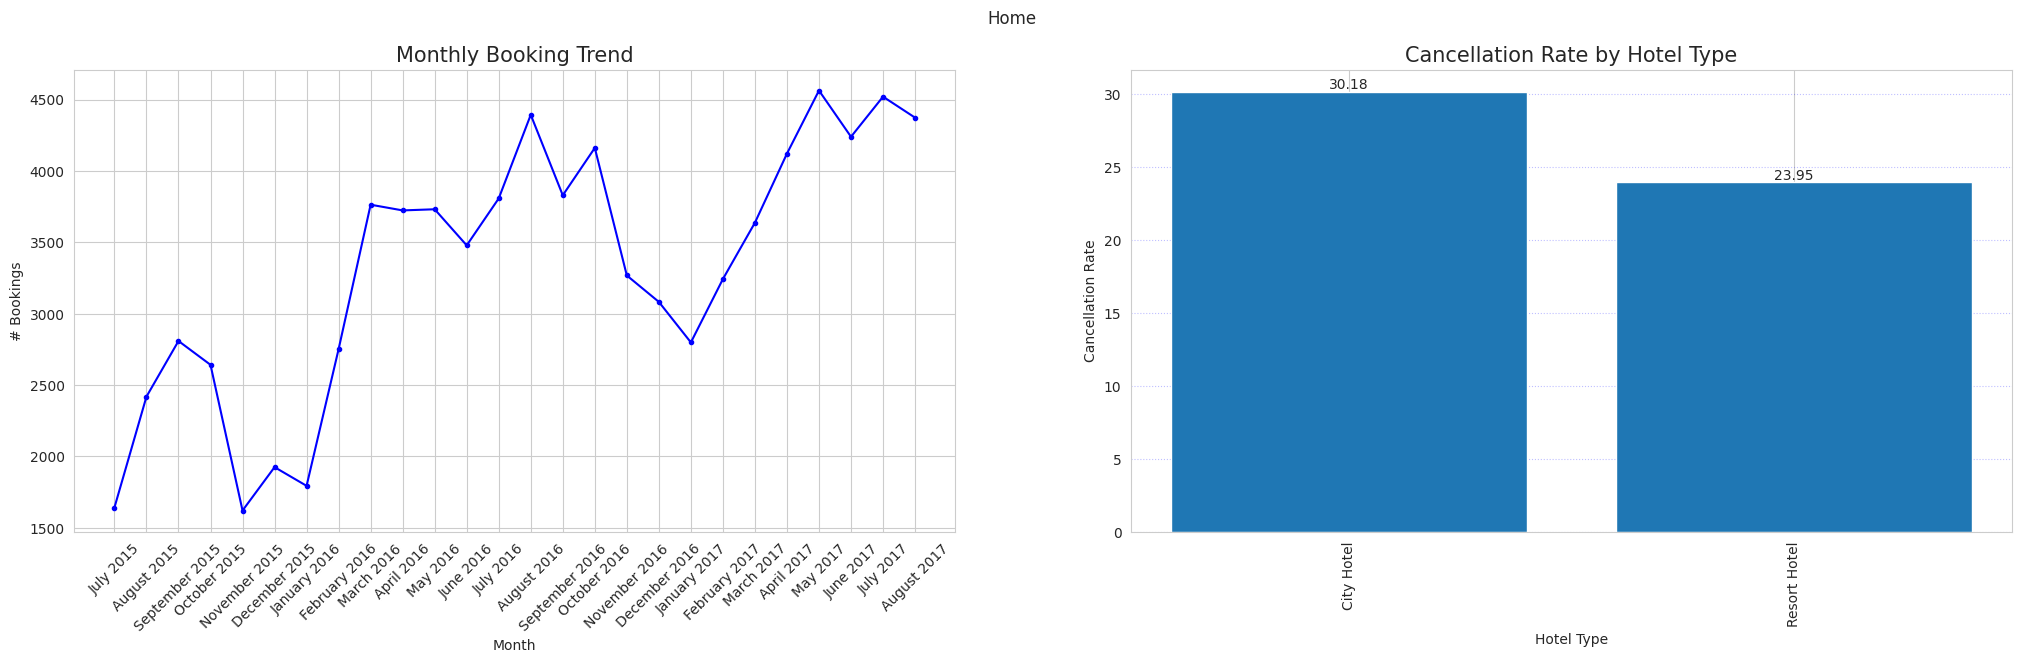

In [ ]:
bookings= df[['arrival_date_month','arrival_date_month_number','arrival_date_year']].value_counts()
bookings.sort_index(level=['arrival_date_year','arrival_date_month_number'],inplace=True)
bookings_df=bookings.to_frame().reset_index()
bookings_df['m-yyyy']=bookings_df['arrival_date_month'].astype(str)+" "+bookings_df['arrival_date_year'].astype(str)

plt.figure(figsize=(25, 6))
plt.subplot(1,2,1)
plt.plot(bookings_df['m-yyyy'],bookings_df['count'],'b.-')
plt.xticks(rotation=45)
plt.title("Monthly Booking Trend", fontsize=15)
plt.xlabel("Month")
plt.ylabel("# Bookings")


Cancellation_hotel = df.groupby('hotel')['is_canceled'].mean() * 100
Cancellation_hotel.sort_values(inplace=True,ascending=False)

plt.subplot(1,2,2)
plt.bar(Cancellation_hotel.index,Cancellation_hotel.values)
plt.xticks(rotation=90)
plt.title("Cancellation Rate by Hotel Type", fontsize=15)
plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Rate")
plt.grid(axis='y',color="b",alpha=0.25,linestyle=":")
for ind,val in enumerate(Cancellation_hotel):
    plt.text(ind,val,round(val,2),ha="center",va="bottom")


plt.suptitle("Home")
plt.show()


### KPI

---



In [ ]:
KPI={'Number of Bookings':df.shape[0],
'Number of Hotels':len(df['hotel'].unique()),
'Averager Daily Rate (ADR)':df['average_daily_rate(ADR)'].mean()}
print(KPI)

{'Number of Bookings': 86323, 'Number of Hotels': 2, 'Averager Daily Rate (ADR)': np.float64(107.33655479999537)}


## Cancellations

---



In [ ]:
fig = make_subplots(rows=3, cols=2,specs=[[{'colspan': 2}, None],[{}, {}],[{}, {}]], subplot_titles=("Monthly Cancellation Trend", "Cancellations By Month", "Cancellation Rate by Market Segment", "Cancellation Rate by Deposit Type",'Cancellation Rate by Customer Type'))
fig.update_layout(height=800, title_text="Cancellations",title_x=0.5)

monthly_cancellations= df[df['is_canceled']==True][['arrival_date_year','arrival_date_month','arrival_date_month_number']].value_counts()
monthly_cancellations.sort_index(level=['arrival_date_year','arrival_date_month_number'],inplace=True)
monthly_cancellations_df=monthly_cancellations.to_frame().reset_index()
monthly_cancellations_df['m-yyyy']=monthly_cancellations_df['arrival_date_month'].astype(str)+" "+monthly_cancellations_df['arrival_date_year'].astype(str)
fig.add_trace(go.Scatter(x=monthly_cancellations_df['m-yyyy'], y=monthly_cancellations_df['count']), row=1, col=1)

monthly_cancellations= df[df['is_canceled']==True][['arrival_date_month','arrival_date_month_number']].value_counts()
monthly_cancellations.sort_index(level='arrival_date_month_number',inplace=True)
monthly_cancellations_df=monthly_cancellations.to_frame().reset_index()
fig.add_trace(go.Scatter(x=monthly_cancellations_df['arrival_date_month'], y=monthly_cancellations_df['count']), row=2, col=1)

Cancellation_customer_type = df.groupby('customer_type')['is_canceled'].mean() * 100
Cancellation_customer_type.sort_values(inplace=True,ascending=False)
fig.add_trace(go.Bar(x=Cancellation_customer_type.index,y=Cancellation_customer_type.values), row=2, col=2)

Cancellation_deposit_type = df.groupby('deposit_type')['is_canceled'].mean() * 100
Cancellation_deposit_type.sort_values(inplace=True,ascending=False)
fig.add_trace(go.Bar(x=Cancellation_deposit_type.index,y=Cancellation_deposit_type.values), row=3, col=1)

Cancellation_market_segment = df.groupby('market_segment_label')['is_canceled'].mean() * 100
Cancellation_market_segment.sort_values(inplace=True,ascending=False)
fig.add_trace(go.Bar(x=Cancellation_market_segment.index,y=Cancellation_market_segment.values), row=3, col=2)

fig.update_xaxes(title_text="Month-year", row=1, col=1)
fig.update_xaxes(title_text="Month", row=2, col=1)
fig.update_xaxes(title_text="Market Segment", row=2, col=2)
fig.update_xaxes(title_text="Deposit Type", row=3, col=1)
fig.update_xaxes(title_text="Customer Type", row=3, col=2)

fig.update_yaxes(title_text="# Cancellations", row=1, col=1)
fig.update_yaxes(title_text="# Cancellations", row=2, col=1)
fig.update_yaxes(title_text="Cancellation Rate (%)", row=2, col=2)
fig.update_yaxes(title_text="Cancellation Rate (%)", row=3, col=1)
fig.update_yaxes(title_text="Cancellation Rate (%)", row=3, col=2)

## Demand & Seasonality

In [ ]:
fig = make_subplots(rows=2, cols=2, specs=[[{}, {}],[{"colspan": 2}, None]],subplot_titles=("Bookings By Month", "Bookings by Arrival Day", 'ADR By Month',''))
fig.update_layout(height=800, title_text="Demand & Seasonality",title_x=0.5)

bookings= df[['arrival_date_month','arrival_date_month_number']].value_counts()
bookings.sort_index(level='arrival_date_month_number',inplace=True)
bookings_df=bookings.to_frame().reset_index()
fig.add_trace(go.Scatter(x=bookings_df['arrival_date_month'], y=bookings_df['count']), row=1, col=1)

bookings_arrival_day= df['arrival_date_day_of_month'].value_counts()
bookings_arrival_day.sort_index(level='arrival_date_day_of_month',inplace=True)
fig.add_trace(go.Bar(x=bookings_arrival_day.index,y=bookings_arrival_day.values), row=1, col=2)

bookings= df.groupby(['arrival_date_month','arrival_date_month_number'])['average_daily_rate(ADR)'].mean()
bookings.sort_index(level='arrival_date_month_number',inplace=True)
bookings_df=bookings.to_frame().reset_index()
fig.add_trace(go.Scatter(x=bookings_df['arrival_date_month'], y=bookings_df['average_daily_rate(ADR)']), row=2, col=1)


fig.update_xaxes(title_text="Month", row=1, col=1)
fig.update_xaxes(title_text="Day", row=1, col=2)
fig.update_xaxes(title_text="Month", row=2, col=1)

fig.update_yaxes(title_text="# Bookings", row=1, col=1)
fig.update_yaxes(title_text="# Bookings", row=1, col=2)
fig.update_yaxes(title_text="ADR", row=2, col=1)


In [ ]:
bookings_country = df.groupby(['country','country_name'])['country'].value_counts()
bookings_country_df=bookings_country.to_frame().reset_index()
bookings_country_df.rename(columns={'count':'Bookings'},inplace=True)
fig = px.choropleth(bookings_country_df, locations="country", color="Bookings", hover_name="country_name",
                    color_continuous_scale=px.colors.sequential.Plasma,
                    title="# Bookings by Country")
fig.show()

## Guest Behavior

---



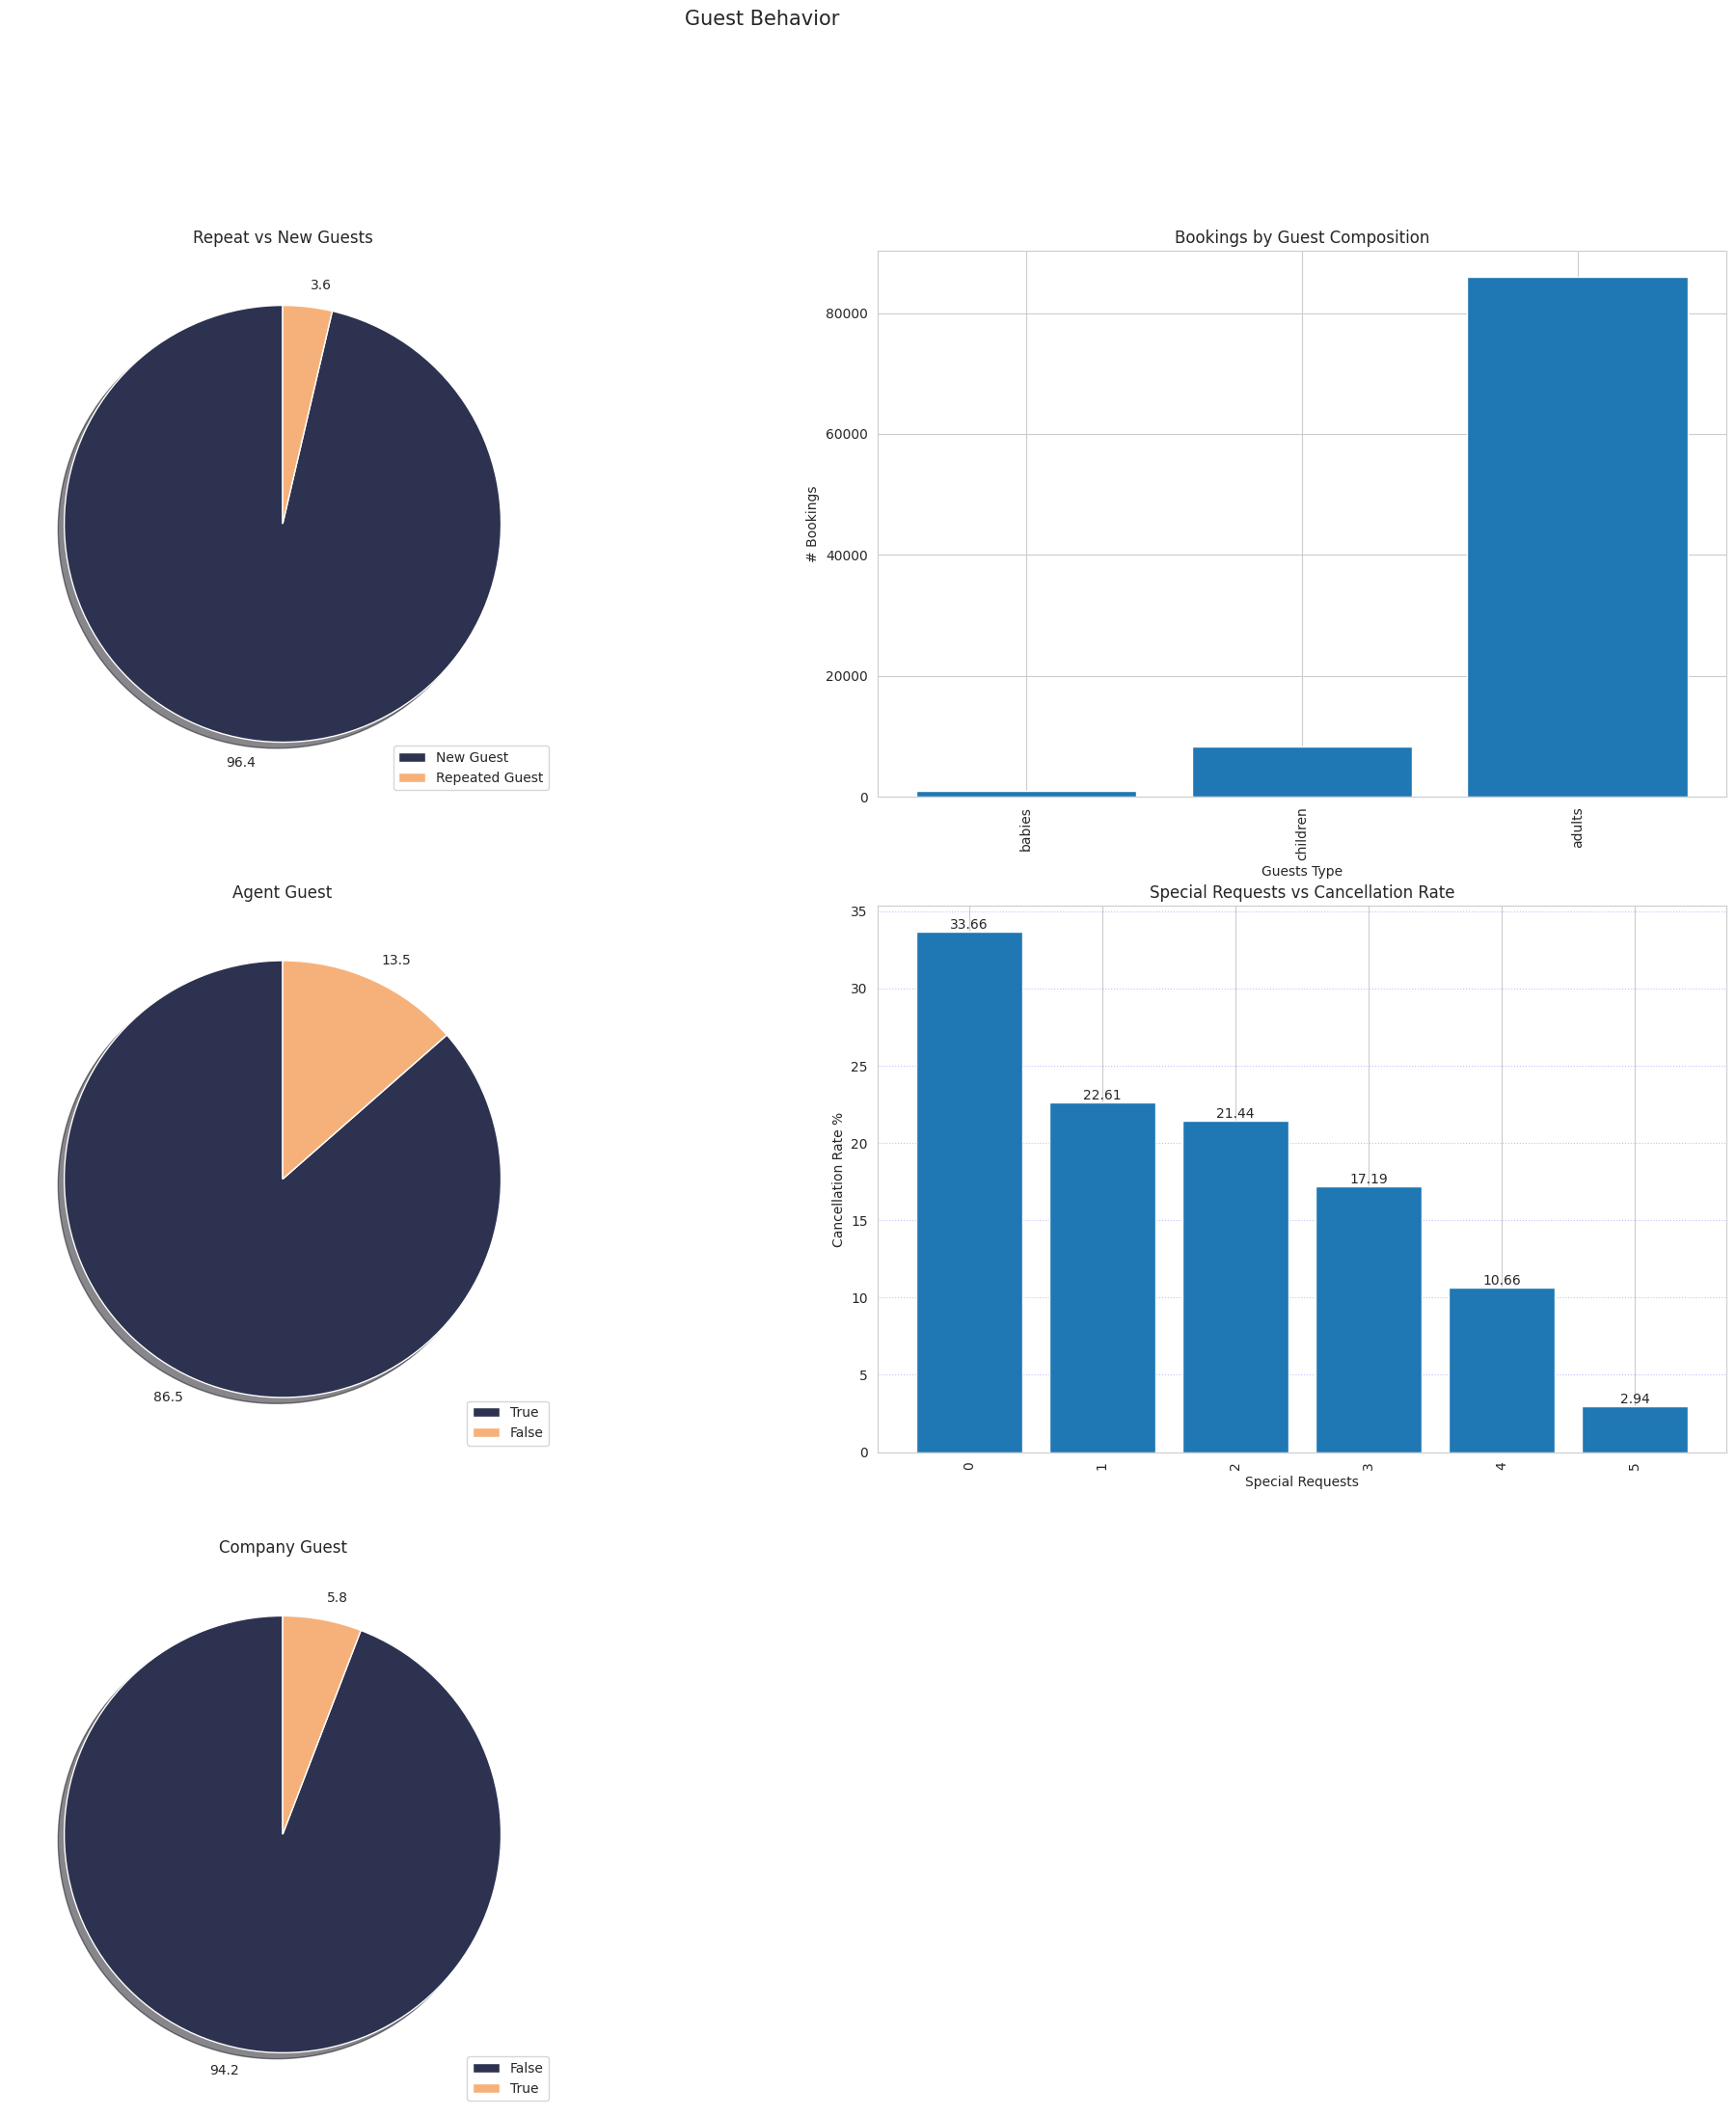

In [ ]:
plt.figure(figsize=(25, 25))
plt.suptitle("Guest Behavior", fontsize=15)
plt.subplot(3,2,1)
repeated_guests=df['is_repeated_guest'].value_counts( )
mylabel = (repeated_guests.values/repeated_guests.values.sum()*100).round(1)
plt.pie(repeated_guests,startangle=90,labels=mylabel,colors=['#2D3250', '#F6B17A'], shadow=True)
plt.title('Repeat vs New Guests')
repeated_guests_df=repeated_guests.reset_index()
repeated_guests_df.loc[repeated_guests_df['is_repeated_guest']==False,'is_repeated_guest']='New Guest'
repeated_guests_df.loc[repeated_guests_df['is_repeated_guest']==True,'is_repeated_guest']='Repeated Guest'
plt.legend(labels=repeated_guests_df['is_repeated_guest'],loc="lower right")

plt.subplot(3,2,2)
adult_bookings = df[df['adults']!=0].shape[0]
children_bookings = df[df['children']!=0].shape[0]
babies_bookings = df[df['babies']!=0].shape[0]
plt.bar(['babies','children','adults'],[babies_bookings,children_bookings,adult_bookings])
plt.xticks(rotation=90)
plt.title('Bookings by Guest Composition')
plt.xlabel("Guests Type")
plt.ylabel("# Bookings")

plt.subplot(3,2,3)
has_agent=df['has_agent'].value_counts( )
mylabel = (has_agent.values/has_agent.values.sum()*100).round(1)
plt.pie(has_agent,startangle=90,labels=mylabel,colors=['#2D3250', '#F6B17A'], shadow=True)
plt.title('Agent Guest')
plt.legend(labels=has_agent.index,loc="lower right")

plt.subplot(3,2,4)
request=df.groupby('total_of_special_requests')['is_canceled'].mean()*100
plt.bar(request.index,request.values)
plt.xticks(rotation=90)
plt.title('Special Requests vs Cancellation Rate')
plt.xlabel("Special Requests")
plt.ylabel("Cancellation Rate %")
plt.grid(axis='y',color="b",alpha=0.25,linestyle=":")
for ind,val in enumerate(request):
    plt.text(ind,val,round(val,2),ha="center",va="bottom")

plt.subplot(3,2,5)
has_company=df['has_company'].value_counts( )
mylabel = (has_company.values/has_company.values.sum()*100).round(1)
plt.pie(has_company,startangle=90,labels=mylabel,colors=['#2D3250', '#F6B17A'], shadow=True)
plt.title('Company Guest')
plt.legend(labels=has_company.index,loc="lower right")


plt.show()





## Revenue & Pricing

In [ ]:
fig = make_subplots(rows=3, cols=2,specs=[[{}, {}],[{}, {}],[{'colspan': 2}, None]], subplot_titles=("ADR Trend by Month", "ADR vs Lead Time", "ADR Distribution by Customer Type", "Average ADR by Room Type",'ADR Distribution by Hotel Type'))
fig.update_layout(height=800, title_text=" Revenue & Pricing",title_x=0.5)

monthly_adr= df.groupby(['arrival_date_month','arrival_date_month_number'])['average_daily_rate(ADR)'].mean()
monthly_adr.sort_index(level='arrival_date_month_number',inplace=True)
monthly_adr_df=monthly_adr.to_frame().reset_index()
fig.add_trace(go.Scatter(x=monthly_adr_df['arrival_date_month'], y=monthly_adr_df['average_daily_rate(ADR)']), row=1, col=1)

lead_adr = df.groupby(['lead_time'])['average_daily_rate(ADR)'].mean()
lead_adr.sort_index(inplace=True)
lead_addr_df=lead_adr.to_frame().reset_index()
fig.add_trace(go.Scatter(x=lead_addr_df['lead_time'], y=lead_addr_df['average_daily_rate(ADR)'],mode='markers'), row=1, col=2)


adr_customer_type = df.groupby('customer_type')['average_daily_rate(ADR)'].mean()
adr_customer_type.sort_values(inplace=True,ascending=False)
fig.add_trace(go.Bar(x=adr_customer_type.index,y=adr_customer_type.values), row=2, col=1)

adr_room_type = df.groupby('assigned_room_type')['average_daily_rate(ADR)'].mean()
adr_room_type.sort_values(inplace=True,ascending=False)
fig.add_trace(go.Bar(x=adr_room_type.index,y=adr_room_type.values), row=2, col=2)

fig.add_trace(go.Box(x=df['hotel'], y=df['average_daily_rate(ADR)']), row=3, col=1)

fig.update_xaxes(title_text="Month", row=1, col=1)
fig.update_xaxes(title_text="Lead Time", row=1, col=2)
fig.update_xaxes(title_text="Customer Type", row=2, col=1)
fig.update_xaxes(title_text="Room Type", row=2, col=2)
fig.update_xaxes(title_text="Hotel", row=3, col=1)



fig.update_yaxes(title_text="average_daily_rate(ADR)", row=1, col=1)
fig.update_yaxes(title_text="average_daily_rate(ADR)", row=1, col=2)
fig.update_yaxes(title_text="average_daily_rate(ADR)", row=2, col=1)
fig.update_yaxes(title_text="average_daily_rate(ADR)", row=2, col=2)
fig.update_yaxes(range=[0, 500], title_text="average_daily_rate(ADR)", row=3, col=1)





## Source & Operations

---



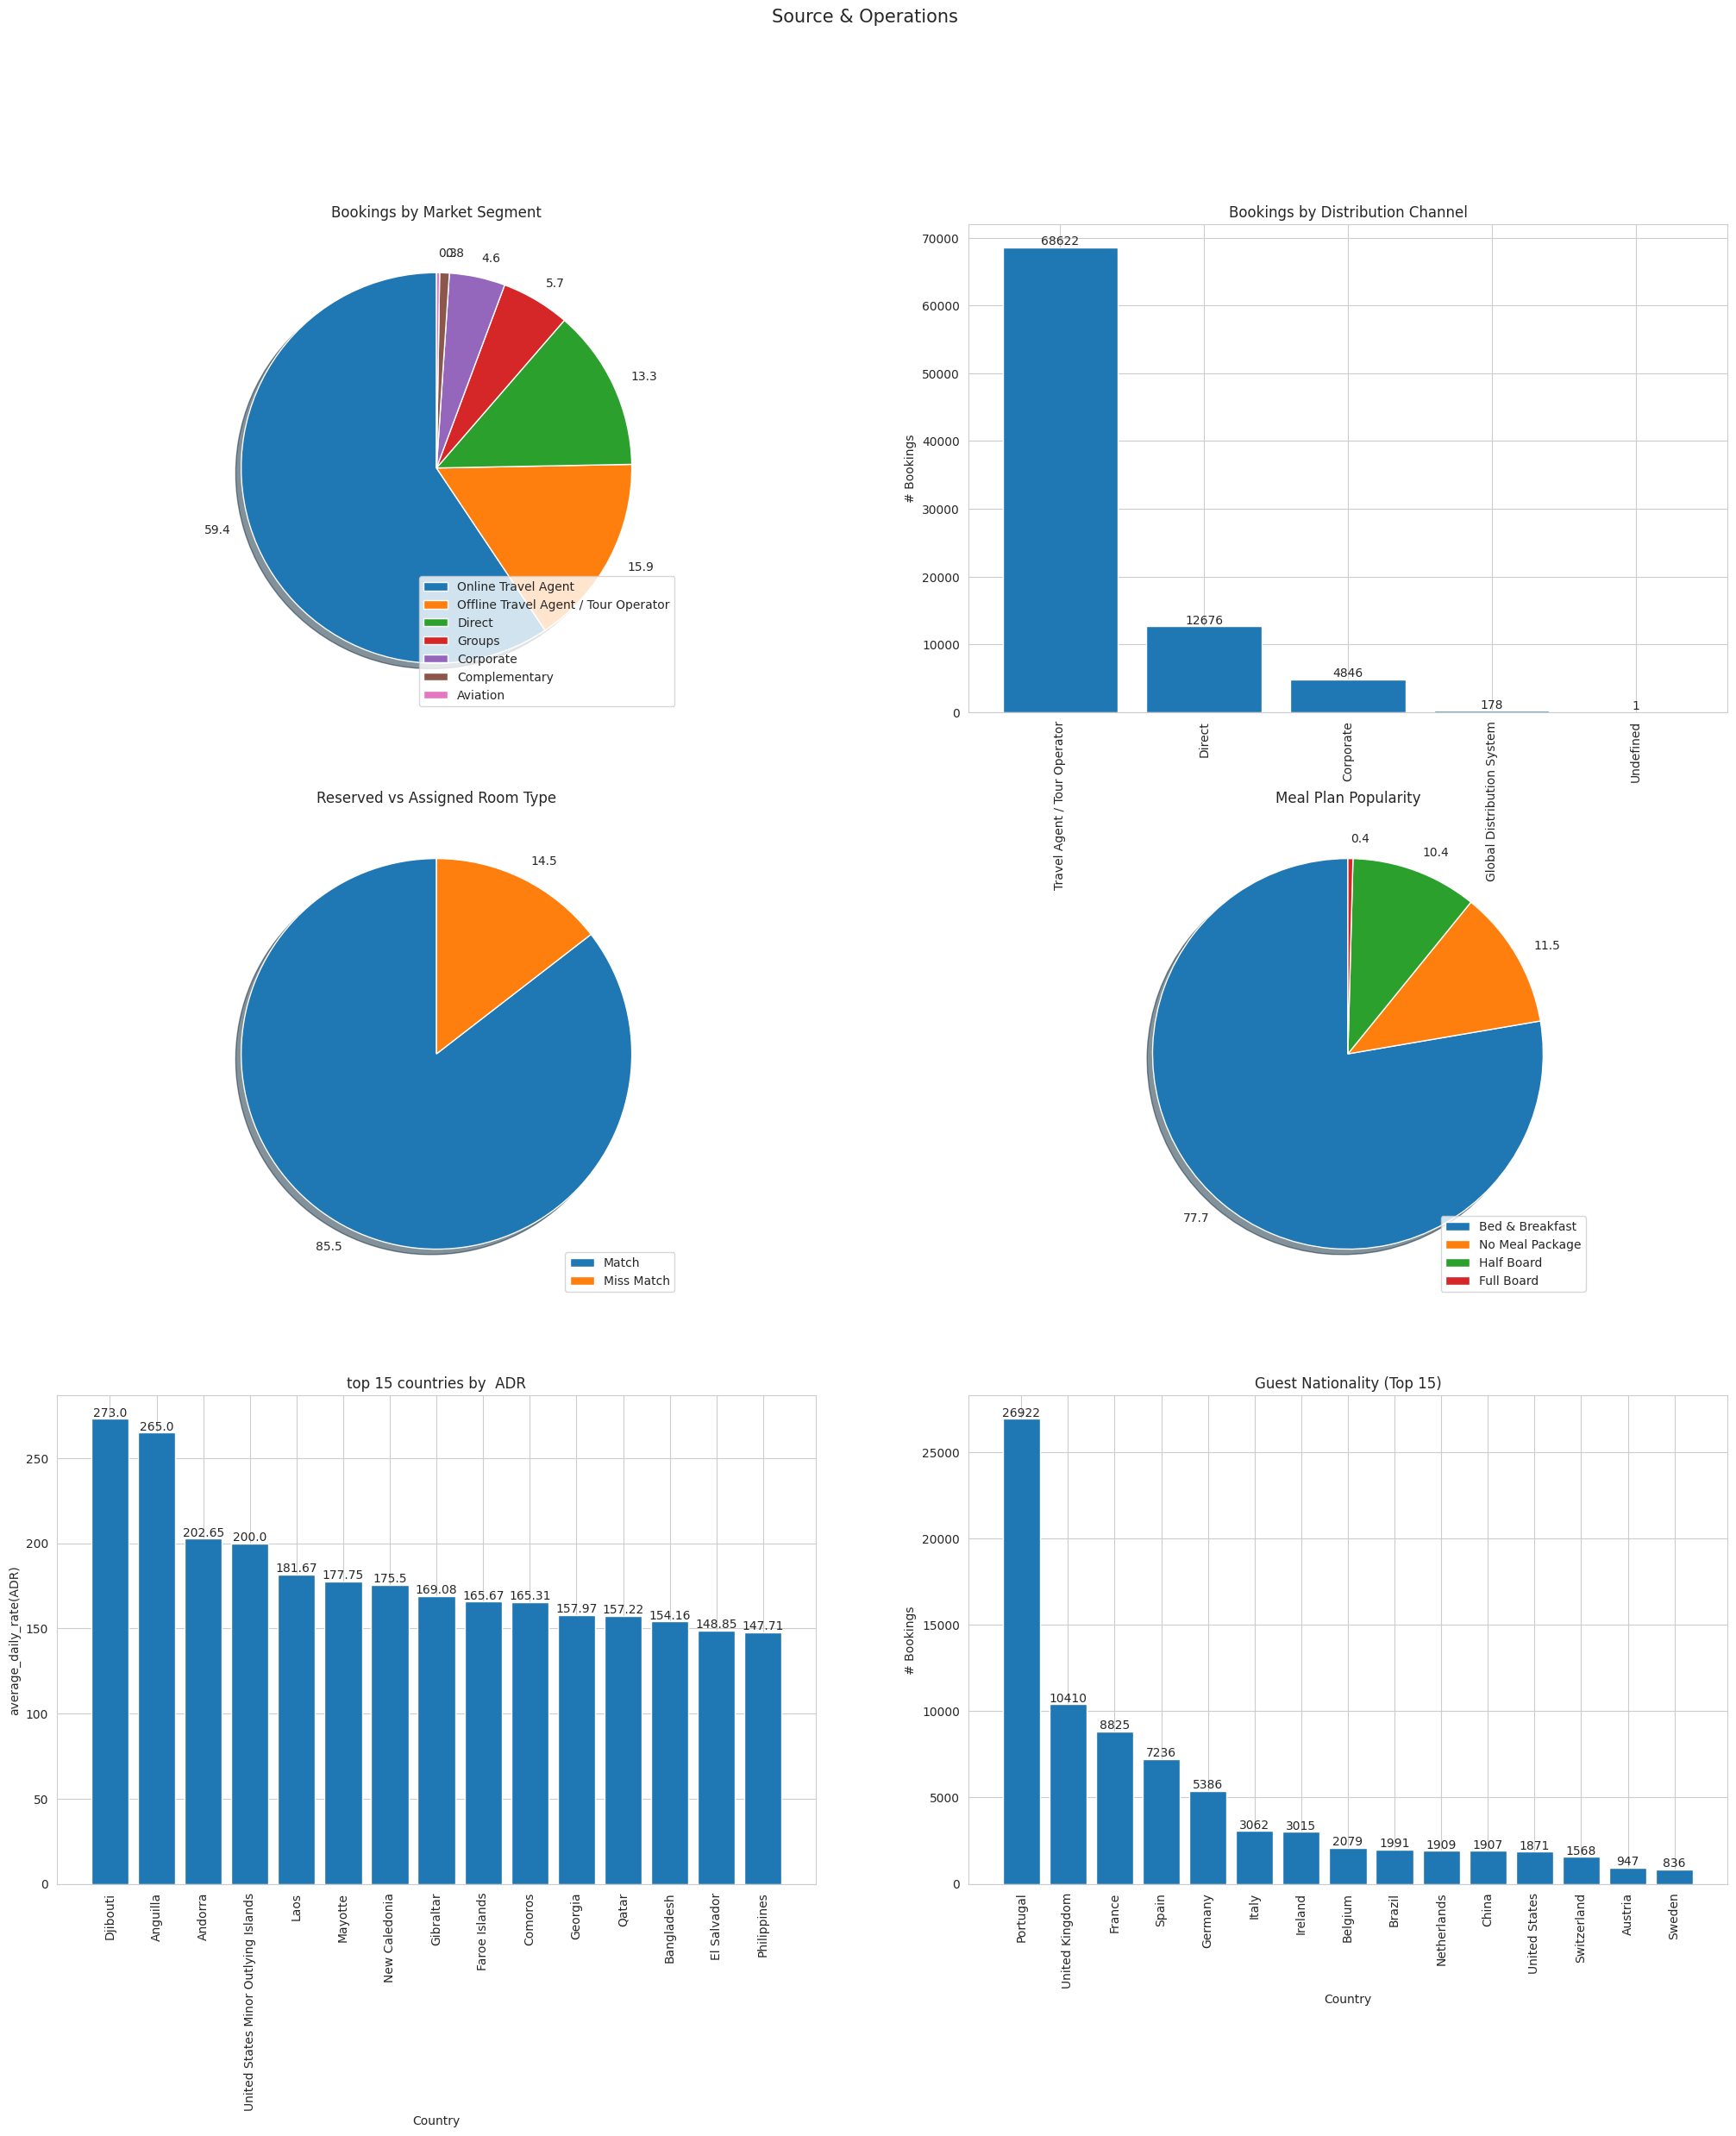

In [ ]:
plt.figure(figsize=(25, 25))
plt.suptitle("Source & Operations", fontsize=15)
plt.subplot(3,2,1)
booking_market=df['market_segment_label'].value_counts( )
mylabel = (booking_market.values/booking_market.values.sum()*100).round(1)
plt.pie(booking_market,startangle=90,labels=mylabel, shadow=True)
plt.title('Bookings by Market Segment')
plt.legend(labels=booking_market.index,loc="lower right")

plt.subplot(3,2,2)
booking_channel=df['distribution_channel_label'].value_counts()
plt.bar(booking_channel.index,booking_channel.values)
plt.xticks(rotation=90)
plt.title('Bookings by Distribution Channel')
plt.xlabel("Distribution Channel")
plt.ylabel("# Bookings")
for ind,val in enumerate(booking_channel):
    plt.text(ind,val,round(val,2),ha="center",va="bottom")

plt.subplot(3,2,3)
miss_match_room=df['miss_match_room'].value_counts( )
mylabel = (miss_match_room.values/miss_match_room.values.sum()*100).round(1)
plt.pie(miss_match_room,startangle=90,labels=mylabel, shadow=True)
plt.title('Reserved vs Assigned Room Type')
miss_match_room_df=miss_match_room.reset_index()
miss_match_room_df.loc[miss_match_room_df['miss_match_room']==False,'miss_match_room']='Match'
miss_match_room_df.loc[miss_match_room_df['miss_match_room']==True,'miss_match_room']='Miss Match'
plt.legend(labels=miss_match_room_df['miss_match_room'],loc="lower right")

plt.subplot(3,2,4)
meal=df['meal_label'].value_counts( )
mylabel = (meal.values/meal.values.sum()*100).round(1)
plt.pie(meal,startangle=90,labels=mylabel, shadow=True)
plt.title('Meal Plan Popularity')
plt.legend(labels=meal.index,loc="lower right")

plt.subplot(3,2,5)
top_nations=df.groupby('country_name')['average_daily_rate(ADR)'].mean()
top_nations.sort_values(inplace=True,ascending=False)
top_nations_df=top_nations.to_frame().reset_index()
top_nations_df=top_nations_df.iloc[:15]
plt.bar(top_nations_df['country_name'],top_nations_df['average_daily_rate(ADR)'])
plt.xticks(rotation=90)
plt.title('top 15 countries by  ADR')
plt.xlabel("Country")
plt.ylabel("average_daily_rate(ADR)")
for ind,val in enumerate(top_nations_df['average_daily_rate(ADR)']):
    plt.text(ind,val,round(val,2),ha="center",va="bottom")

plt.subplot(3,2,6)
top_nations=df['country_name'].value_counts()
top_nations.sort_values(inplace=True,ascending=False)
top_nations_df=top_nations.to_frame().reset_index()
top_nations_df=top_nations_df.iloc[:15]
plt.bar(top_nations_df['country_name'],top_nations_df['count'])
plt.xticks(rotation=90)
plt.title('Guest Nationality (Top 15)')
plt.xlabel("Country")
plt.ylabel("# Bookings")
for ind,val in enumerate(top_nations_df['count']):
    plt.text(ind,val,val,ha="center",va="bottom")

plt.show()
